In [2]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from affine import Affine

tif_file = "IslandsDEMv1.0_2x2m_zmasl_isn93_57.tif"

xmin = 369702.8
xmax = 374398.8
ymin = 407778.9
ymax = 411690.2

target_resolution = 10  # meters
original_resolution = 2  # meters

scale = target_resolution / original_resolution  # 5

with rasterio.open(tif_file) as src:

    # Create window from bounds
    window = from_bounds(
        xmin,
        ymin,
        xmax,
        ymax,
        src.transform
    )

    # Original subset size
    out_height = int(window.height / scale)
    out_width = int(window.width / scale)

    # Read + resample
    dem = src.read(
        1,
        window=window,
        out_shape=(out_height, out_width),
        resampling=Resampling.bilinear
    )

    # Original transform for subset
    transform = src.window_transform(window)

    # Update transform for new resolution
    new_transform = transform * Affine.scale(scale)

    # Copy metadata
    profile = src.profile.copy()

    # Update metadata
    profile.update({
        "height": out_height,
        "width": out_width,
        "transform": new_transform
    })

    # Save output
    with rasterio.open(
        "subset_dem.tif",
        "w",
        **profile
    ) as dst:

        dst.write(dem, 1)

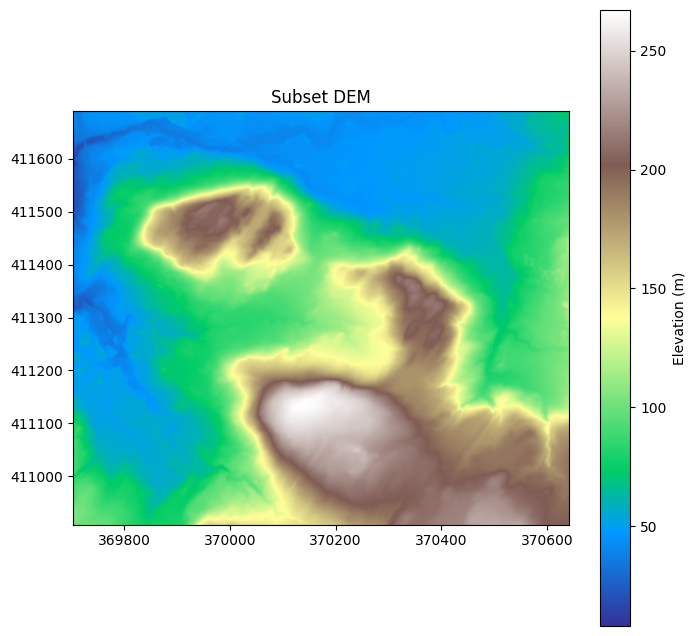

In [4]:
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(8, 8))

img = show(
    dem,
    transform=transform,
    ax=ax,
    cmap="terrain"
)

# add colorbar
cbar = plt.colorbar(
    img.get_images()[0],
    ax=ax
)

cbar.set_label("Elevation (m)")

ax.set_title("Subset DEM")

plt.show()

In [5]:
with rasterio.open("subset_dem.tif") as src:

    print(src.crs)
    print(src.bounds)
    print(src.res)
    print(src.width, src.height)

EPSG:3057
BoundingBox(left=369702.8, bottom=407780.2, right=374392.8, top=411690.2)
(10.0, 10.0)
469 391
